Mô hình 1 – ANN với 1 lớp ẩn (4 nơ-ron)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [2]:
locals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'import numpy as np\nimport matplotlib.pyplot as plt\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense\nfrom tensorflow.keras.optimizers import Adam',
  'locals()'],
 '_oh': {},
 '_dh': [WindowsPath('d:/File cá nhân/Giới thiệu học sâu/lab4')],
 'In': ['',
  'import numpy as np\nimport matplotlib.pyplot as plt\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense\nfrom tensorflow.keras.optimizers import Adam',
  'locals()'],
 'Out': {},
 'get_ipython': <bound method InteractiveShell.get_ipython of <ipykernel.zmqshell.ZMQInteractiveShell object at 0x000001D74FADB380>>,
 'exit': <IPython.core.autocall.ZMQExitAutocall at 0x1d74fb80c20>,
 '

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# Tạo dữ liệu
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

# Chuẩn hóa
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Chia train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
model_4 = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model_4.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_4 = model_4.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_4, acc_4 = model_4.evaluate(X_test, y_test, verbose=0)

print("Model 4 neurons - Loss:", loss_4)
print("Model 4 neurons - Accuracy:", acc_4)


C:\Users\giahu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 4 neurons - Loss: 0.2833339273929596
Model 4 neurons - Accuracy: 0.8650000095367432


Mô hình 2 – Tăng số nơ-ron lớp ẩn lên 8

In [5]:
model_8 = Sequential([
    Dense(8, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model_8.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_8 = model_8.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_8, acc_8 = model_8.evaluate(X_test, y_test, verbose=0)

print("Model 8 neurons - Loss:", loss_8)
print("Model 8 neurons - Accuracy:", acc_8)


Model 8 neurons - Loss: 0.133310467004776
Model 8 neurons - Accuracy: 0.9649999737739563


Mô hình 3 – ANN với 2 lớp ẩn (8 + 6 nơ-ron)
Cấu trúc:

Input: 2 nơ-ron

Hidden layer 1: 8 nơ-ron (ReLU)

Hidden layer 2: 6 nơ-ron (ReLU)

Output: 1 nơ-ron (Sigmoid)

In [6]:
model_8_6 = Sequential([
    Dense(8, activation='relu', input_shape=(2,)),
    Dense(6, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_8_6.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_8_6 = model_8_6.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_8_6, acc_8_6 = model_8_6.evaluate(X_test, y_test, verbose=0)

print("Model 8+6 neurons - Loss:", loss_8_6)
print("Model 8+6 neurons - Accuracy:", acc_8_6)


Model 8+6 neurons - Loss: 0.04686705768108368
Model 8+6 neurons - Accuracy: 0.9750000238418579


Nhận xét và phân tích
So sánh hàm mất mát (Loss)

Mô hình 4 nơ-ron có loss cao nhất do khả năng biểu diễn hạn chế.

Mô hình 8 nơ-ron cho loss thấp hơn nhờ số lượng tham số tăng.

Mô hình 8 + 6 nơ-ron có loss thấp nhất vì mạng sâu hơn học được các đặc trưng phức tạp hơn.


So sánh độ chính xác (Accuracy)

Độ chính xác cải thiện khi tăng số nơ-ron và số lớp ẩn.

Tuy nhiên, mức cải thiện không tuyến tính, phụ thuộc vào độ phức tạp của dữ liệu.

Mô hình nhiều lớp hơn có nguy cơ overfitting nếu dữ liệu nhỏ.

Kết luận
Việc tăng số nơ-ron và số lớp ẩn giúp mô hình ANN học tốt hơn, tuy nhiên cần cân nhắc giữa hiệu suất và độ phức tạp để tránh overfitting và tăng thời gian huấn luyện.

Phần 2

Model dùng logits

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


In [8]:
model_logits = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='relu'),
    Dense(1)  # KHÔNG sigmoid
])

model_logits.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_logits = model_logits.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_logits, acc_logits = model_logits.evaluate(X_test, y_test, verbose=0)

print("BCEWithLogitsLoss - Loss:", loss_logits)
print("BCEWithLogitsLoss - Accuracy:", acc_logits)


BCEWithLogitsLoss - Loss: 0.2598203718662262
BCEWithLogitsLoss - Accuracy: 0.8799999952316284


Thử nghiệm 2: SGD thay cho Adam
Model gốc (có Sigmoid)

In [9]:
from tensorflow.keras.optimizers import SGD


In [10]:
model_sgd = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_sgd, acc_sgd = model_sgd.evaluate(X_test, y_test, verbose=0)

print("SGD + BCELoss - Loss:", loss_sgd)
print("SGD + BCELoss - Accuracy:", acc_sgd)


SGD + BCELoss - Loss: 0.2911841869354248
SGD + BCELoss - Accuracy: 0.8650000095367432


BCEWithLogitsLoss vs BCELoss

BinaryCrossentropy(from_logits=True):

Gộp Sigmoid + BCE

Ổn định số học hơn

Gradient tốt hơn khi output lớn/nhỏ

binary_crossentropy:

Cần Sigmoid riêng

Dễ gặp vấn đề số học

Kết luận:
BCEWithLogitsLoss thường cho loss thấp hơn và hội tụ ổn định hơn.


SGD vs Adam

SGD:

Cập nhật đều

Hội tụ chậm

Phụ thuộc learning rate

Adam:

Điều chỉnh learning rate tự động

Hội tụ nhanh

Ổn định hơn

Kết luận:
Adam cho loss giảm nhanh hơn và accuracy cao hơn trong cùng số epoch.

Phần 3

In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import BinaryCrossentropy


Trường hợp 1
Cấu trúc 2–4–1 | Adam | BCELoss

In [12]:
model_241_adam = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_241_adam.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

history_241_adam = model_241_adam.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_241_adam = history_241_adam.history['loss']


Trường hợp 2
Cấu trúc 2–8–1 | Adam | BCELoss

In [13]:
model_281_adam = Sequential([
    Input(shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_281_adam.compile(
    optimizer=Adam(),
    loss='binary_crossentropy'
)

history_281_adam = model_281_adam.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_281_adam = history_281_adam.history['loss']


Trường hợp 3
Cấu trúc 2–4–1 | SGD | BCELoss

In [14]:
model_241_sgd = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_241_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='binary_crossentropy'
)

history_241_sgd = model_241_sgd.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    verbose=0
)

loss_241_sgd = history_241_sgd.history['loss']


Vẽ đồ thị loss theo epoch

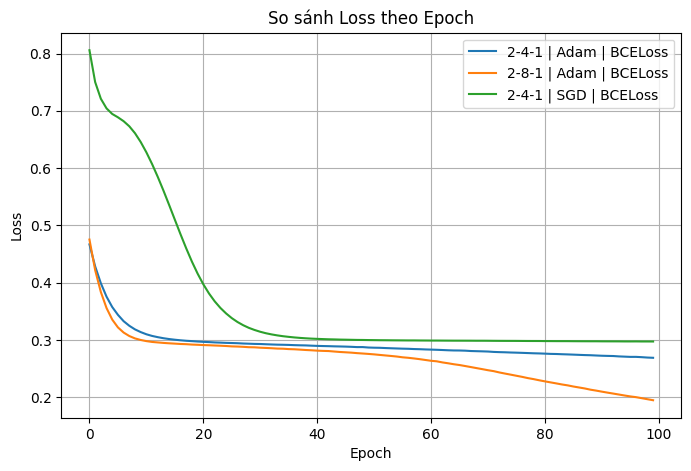

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(loss_241_adam, label='2-4-1 | Adam | BCELoss')
plt.plot(loss_281_adam, label='2-8-1 | Adam | BCELoss')
plt.plot(loss_241_sgd, label='2-4-1 | SGD | BCELoss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('So sánh Loss theo Epoch')
plt.legend()
plt.grid(True)

plt.show()


Trường hợp 2–8–1 | Adam | BCELoss có tốc độ giảm loss nhanh nhất

Nguyên nhân:

Số nơ-ron nhiều hơn → khả năng biểu diễn tốt hơn

Adam tự điều chỉnh learning rate → hội tụ nhanh

Mất mát giảm chậm nhất ở trường hợp nào?

Trường hợp 2–4–1 | SGD | BCELoss

Nguyên nhân:

SGD cập nhật trọng số tuyến tính

Learning rate cố định

Không có cơ chế thích nghi như Adam

Có hiện tượng loss dao động không? Vì sao?

Ở mô hình dùng SGD, loss có thể dao động nhẹ

Nguyên nhân:

Gradient thay đổi mạnh giữa các batch

Learning rate không được điều chỉnh tự động

Ngược lại, Adam cho đường loss mượt và ổn định hơn

Kết luận chung

Kiến trúc mạng và thuật toán tối ưu hóa ảnh hưởng trực tiếp đến tốc độ hội tụ

Mô hình nhiều nơ-ron kết hợp Adam cho hiệu quả học tốt hơn

SGD cần tinh chỉnh learning rate để tránh hội tụ chậm hoặc dao động